<a href="https://colab.research.google.com/github/famosaade/famosaade/blob/main/Energy_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('energy_consumption.csv')
df.info()
print('\nMISSING VALUES PER COLUMN')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')
print('No missing values found — dataset is complete.')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       5000 non-null   object 
 1   customer_type     5000 non-null   object 
 2   regions           5000 non-null   object 
 3   building_size_m2  5000 non-null   int64  
 4   occupants         5000 non-null   int64  
 5   energy_cost_brl   5000 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 234.5+ KB

MISSING VALUES PER COLUMN
customer_id         0
customer_type       0
regions             0
building_size_m2    0
occupants           0
energy_cost_brl     0
dtype: int64

Total missing values: 0
No missing values found — dataset is complete.


In [ ]:

print('DUPLICATE VALUES PER COLUMN')
duplicate_ = df.duplicated().sum()
print(duplicate_)
print(f'\nTotal duplicate values: {duplicate_.sum()}')
print('No duplicate values found')

total_customers = df['customer_id'].value_counts().sum()
print(f'\nTotal number of customers {total_customers} ')

print('\nUNIQUE VALUES')
print('customer_type:', df['customer_type'].unique())
print('regions:', df['regions'].unique())
print('building sizes:', sorted(df['building_size_m2'].unique()))
print('occupants values:', sorted(df['occupants'].unique()))

DUPLICATE VALUES PER COLUMN
0

Total duplicate values: 0
No duplicate values found

Total number of customers 5000 

UNIQUE VALUES
customer_type: ['residential' 'commercial']
regions: ['Northeast' 'Midwest' 'Southeast' 'North' 'South']
building sizes: [np.int64(17), np.int64(24), np.int64(45), np.int64(52), np.int64(77)]
occupants values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [ ]:
print('CUSTOMER TYPE DISTRIBUTION')
print(df['customer_type'].value_counts())
print(f'\nResidential %: {df["customer_type"].value_counts(normalize=True)["residential"]*100}%')
print(f'Commercial %: {df["customer_type"].value_counts(normalize=True)["commercial"]*100}%')

print('\nREGION')
print(df['regions'].value_counts())

CUSTOMER TYPE DISTRIBUTION
customer_type
residential    3261
commercial     1739
Name: count, dtype: int64

Residential %: 65.22%
Commercial %: 34.78%

REGION
regions
Midwest      2012
Northeast    1266
North         759
South         482
Southeast     481
Name: count, dtype: int64


In [ ]:
df[['building_size_m2', 'occupants', 'energy_cost_brl']].describe()


,building_size_m2,occupants,energy_cost_brl
count,5000.00000,5000.000000,5000.000000
mean,39.57620,2.301800,86.874028
std,17.51638,1.032729,24.383261
min,17.00000,1.000000,52.520000
25%,24.00000,1.000000,68.557500
50%,45.00000,2.000000,83.715000
75%,45.00000,3.000000,98.242500
max,77.00000,4.000000,158.610000


In [ ]:
df.groupby('customer_type')['energy_cost_brl'].describe()

,count,mean,std,min,25%,50%,75%,max
customer_type,,,,,,,,
commercial,1739.0,86.353076,23.482404,52.64,69.215,83.63,97.48,158.61
residential,3261.0,87.151837,24.849394,52.52,68.210,83.78,98.71,158.52


In [ ]:
df.groupby('regions')['energy_cost_brl'].describe()

,count,mean,std,min,25%,50%,75%,max
regions,,,,,,,,
Midwest,2012.0,86.307266,23.958900,52.53,68.1950,83.210,97.8650,158.52
North,759.0,87.594638,24.926193,52.52,69.3250,83.650,99.0400,158.51
Northeast,1266.0,86.927401,24.765236,52.53,67.8775,84.490,98.1600,158.45
South,482.0,86.743942,24.048317,52.70,69.3000,83.625,98.2975,158.61
Southeast,481.0,88.097547,24.622257,52.80,70.7400,85.250,98.1500,158.19


In [ ]:
df.groupby('occupants')['energy_cost_brl'].mean()

,energy_cost_brl
occupants,
1,79.147814
2,78.914681
3,78.314694
4,132.443227


In [ ]:
df.groupby('occupants')['energy_cost_brl'].describe()

,count,mean,std,min,25%,50%,75%,max
occupants,,,,,,,,
1,1386.0,79.147814,14.885741,52.53,66.6475,79.475,92.045,103.84
2,1472.0,78.914681,14.583484,52.52,66.9675,79.370,91.220,103.84
3,1389.0,78.314694,15.166997,52.55,65.1500,77.910,91.450,103.81
4,753.0,132.443227,15.965840,103.86,118.7800,133.380,146.230,158.61


In [ ]:
df.groupby('building_size_m2')['energy_cost_brl'].describe()

,count,mean,std,min,25%,50%,75%,max
building_size_m2,,,,,,,,
17,744.0,79.272823,14.847717,52.53,67.0600,79.760,91.6675,103.84
24,1249.0,78.612058,14.687885,52.55,66.3100,78.920,91.4800,103.84
45,1976.0,93.189150,28.148904,52.53,70.9025,88.600,107.1025,158.61
52,522.0,92.131149,27.238057,52.63,70.8200,87.695,103.6275,157.78
77,509.0,88.350648,26.806947,52.52,67.5100,83.550,101.0000,157.83


**VISUALIZATION**

(array([244., 245., 233., 232., 226., 254., 256., 247., 256., 242., 241.,
        260., 275., 243., 275., 257., 262.,  41.,  41.,  38.,  38.,  34.,
         35.,  41.,  40.,  50.,  34.,  42.,  43.,  47.,  42.,  49.,  34.,
         57.,  46.]),
 array([ 52.52      ,  55.55114286,  58.58228571,  61.61342857,
         64.64457143,  67.67571429,  70.70685714,  73.738     ,
         76.76914286,  79.80028571,  82.83142857,  85.86257143,
         88.89371429,  91.92485714,  94.956     ,  97.98714286,
        101.01828571, 104.04942857, 107.08057143, 110.11171429,
        113.14285714, 116.174     , 119.20514286, 122.23628571,
        125.26742857, 128.29857143, 131.32971429, 134.36085714,
        137.392     , 140.42314286, 143.45428571, 146.48542857,
        149.51657143, 152.54771429, 155.57885714, 158.61      ]),
 <BarContainer object of 35 artists>)

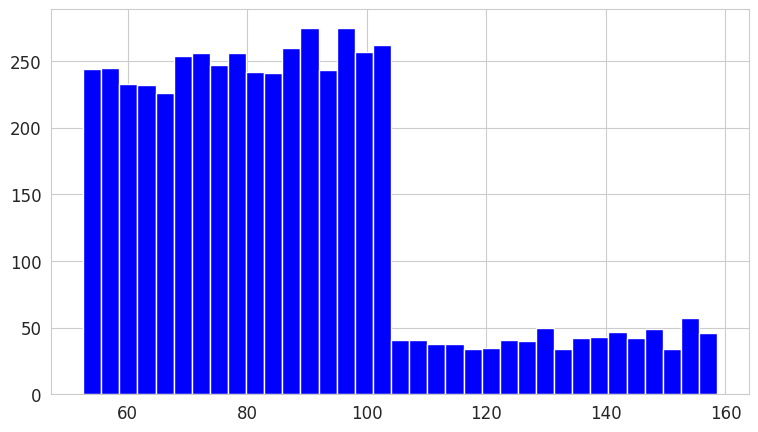

In [ ]:
# energy cost distribution
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 12
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['energy_cost_brl'], bins=35, color='b', edgecolor='white')


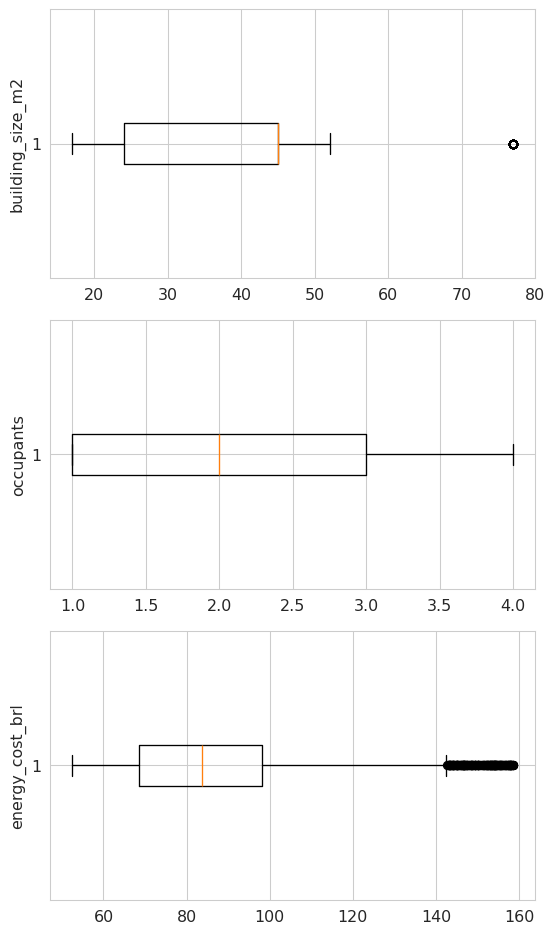

In [ ]:
df.describe()

# Select only numerical columns for boxplots
numeric_cols = df.select_dtypes(include=np.number).columns

fig, axs = plt.subplots(len(numeric_cols), 1, figsize=(6, 10), dpi = 95)
for i, col in enumerate(numeric_cols):
  axs[i].boxplot(df[col], vert=False)
  axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

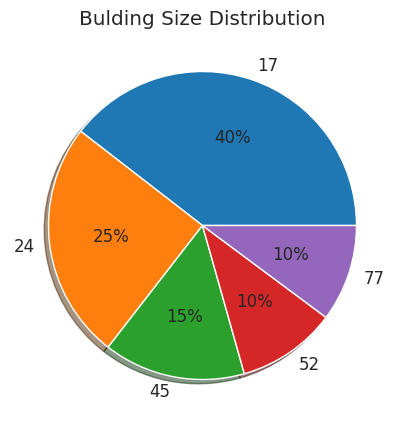

In [ ]:
plt.pie(df['building_size_m2'].value_counts(), labels=[
        '17', '24', '45', '52', '77'], autopct='%.f%%', shadow=True)
plt.title('Bulding Size Distribution')
plt.show()

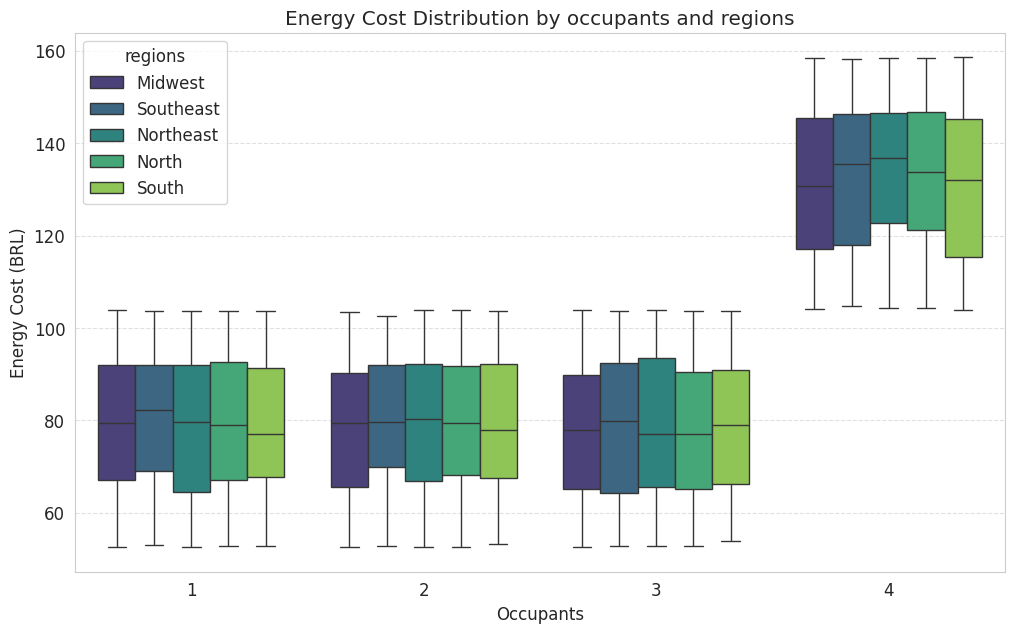

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='occupants', y='energy_cost_brl', data=df, palette='viridis', hue='regions', legend=True)
plt.title('Energy Cost Distribution by occupants and regions')
plt.xlabel('Occupants')
plt.ylabel('Energy Cost (BRL)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

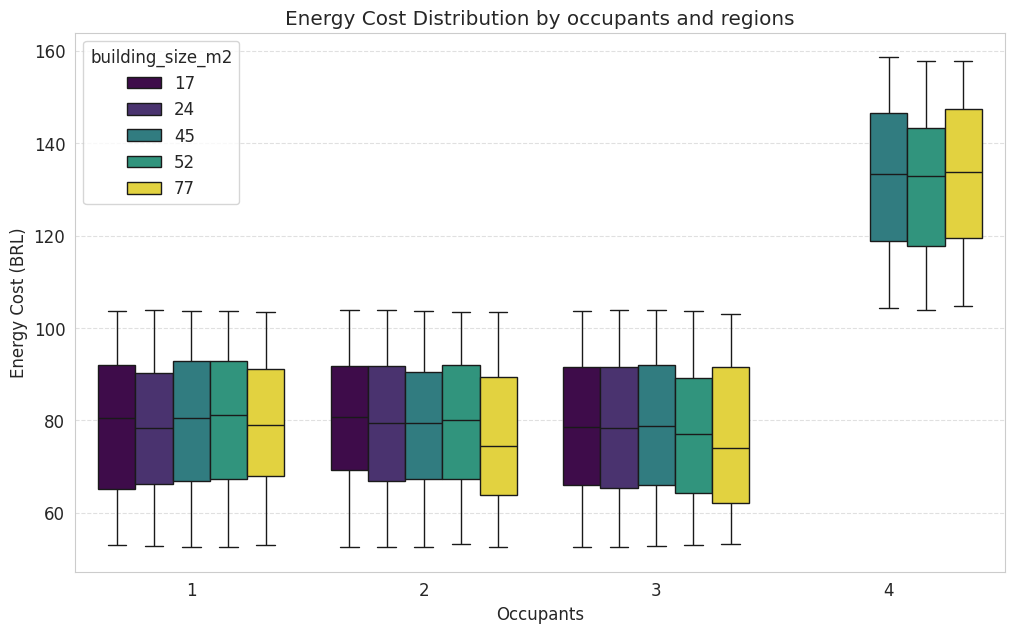

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='occupants', y='energy_cost_brl', data=df, palette='viridis', hue='building_size_m2', legend=True)
plt.title('Energy Cost Distribution by occupants and regions')
plt.xlabel('Occupants')
plt.ylabel('Energy Cost (BRL)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
filtered_data_all_sizes = df[
    (df['occupants'] == 3) &
    (df['regions'] == 'Midwest')
]

print(filtered_data_all_sizes.head())
print(f"\nShape of filtered_data_all_sizes: {filtered_data_all_sizes.shape}")

      customer_id customer_type  regions  building_size_m2  occupants  \
6   CUSTOMER_0007   residential  Midwest                17          3   
11  CUSTOMER_0012    commercial  Midwest                45          3   
12  CUSTOMER_0013    commercial  Midwest                77          3   
20  CUSTOMER_0021   residential  Midwest                24          3   
21  CUSTOMER_0022   residential  Midwest                17          3   

    energy_cost_brl  
6             52.99  
11            76.71  
12            70.67  
20           103.67  
21            80.82  

Shape of filtered_data_all_sizes: (572, 6)


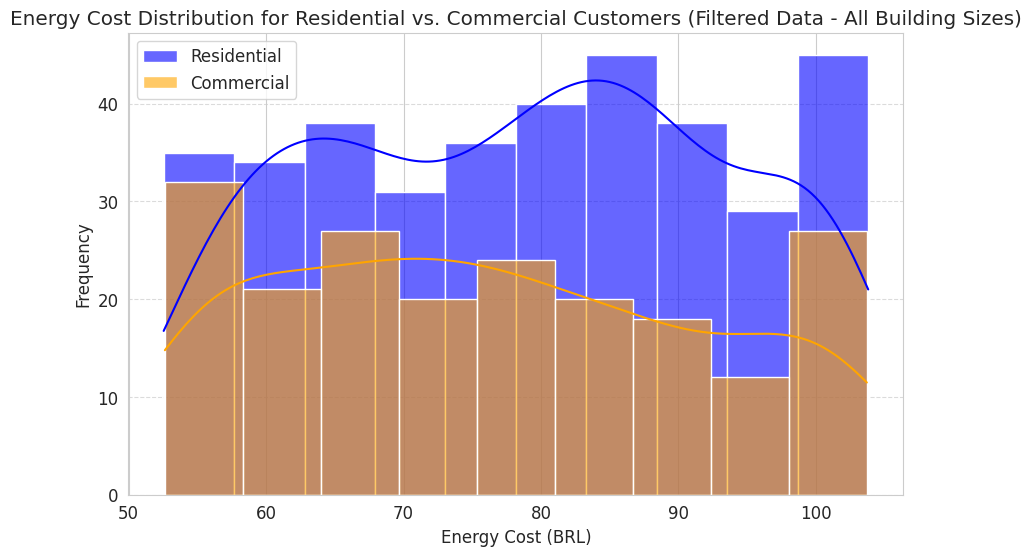

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_data_all_sizes[filtered_data_all_sizes['customer_type'] == 'residential'], x='energy_cost_brl', color='blue', label='Residential', kde=True, alpha=0.6)
sns.histplot(data=filtered_data_all_sizes[filtered_data_all_sizes['customer_type'] == 'commercial'], x='energy_cost_brl', color='orange', label='Commercial', kde=True, alpha=0.6)
plt.title('Energy Cost Distribution for Residential vs. Commercial Customers (Filtered Data - All Building Sizes)')
plt.xlabel('Energy Cost (BRL)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
midwest_df = df[df['regions'] == 'Midwest']

print("Filtered Midwest DataFrame head:")
print(midwest_df.head())
print(f"\nShape of midwest_df: {midwest_df.shape}")

Filtered Midwest DataFrame head:
      customer_id customer_type  regions  building_size_m2  occupants  \
1   CUSTOMER_0002    commercial  Midwest                24          1   
6   CUSTOMER_0007   residential  Midwest                17          3   
9   CUSTOMER_0010    commercial  Midwest                45          4   
11  CUSTOMER_0012    commercial  Midwest                45          3   
12  CUSTOMER_0013    commercial  Midwest                77          3   

    energy_cost_brl  
1             55.26  
6             52.99  
9            158.14  
11            76.71  
12            70.67  

Shape of midwest_df: (2012, 6)


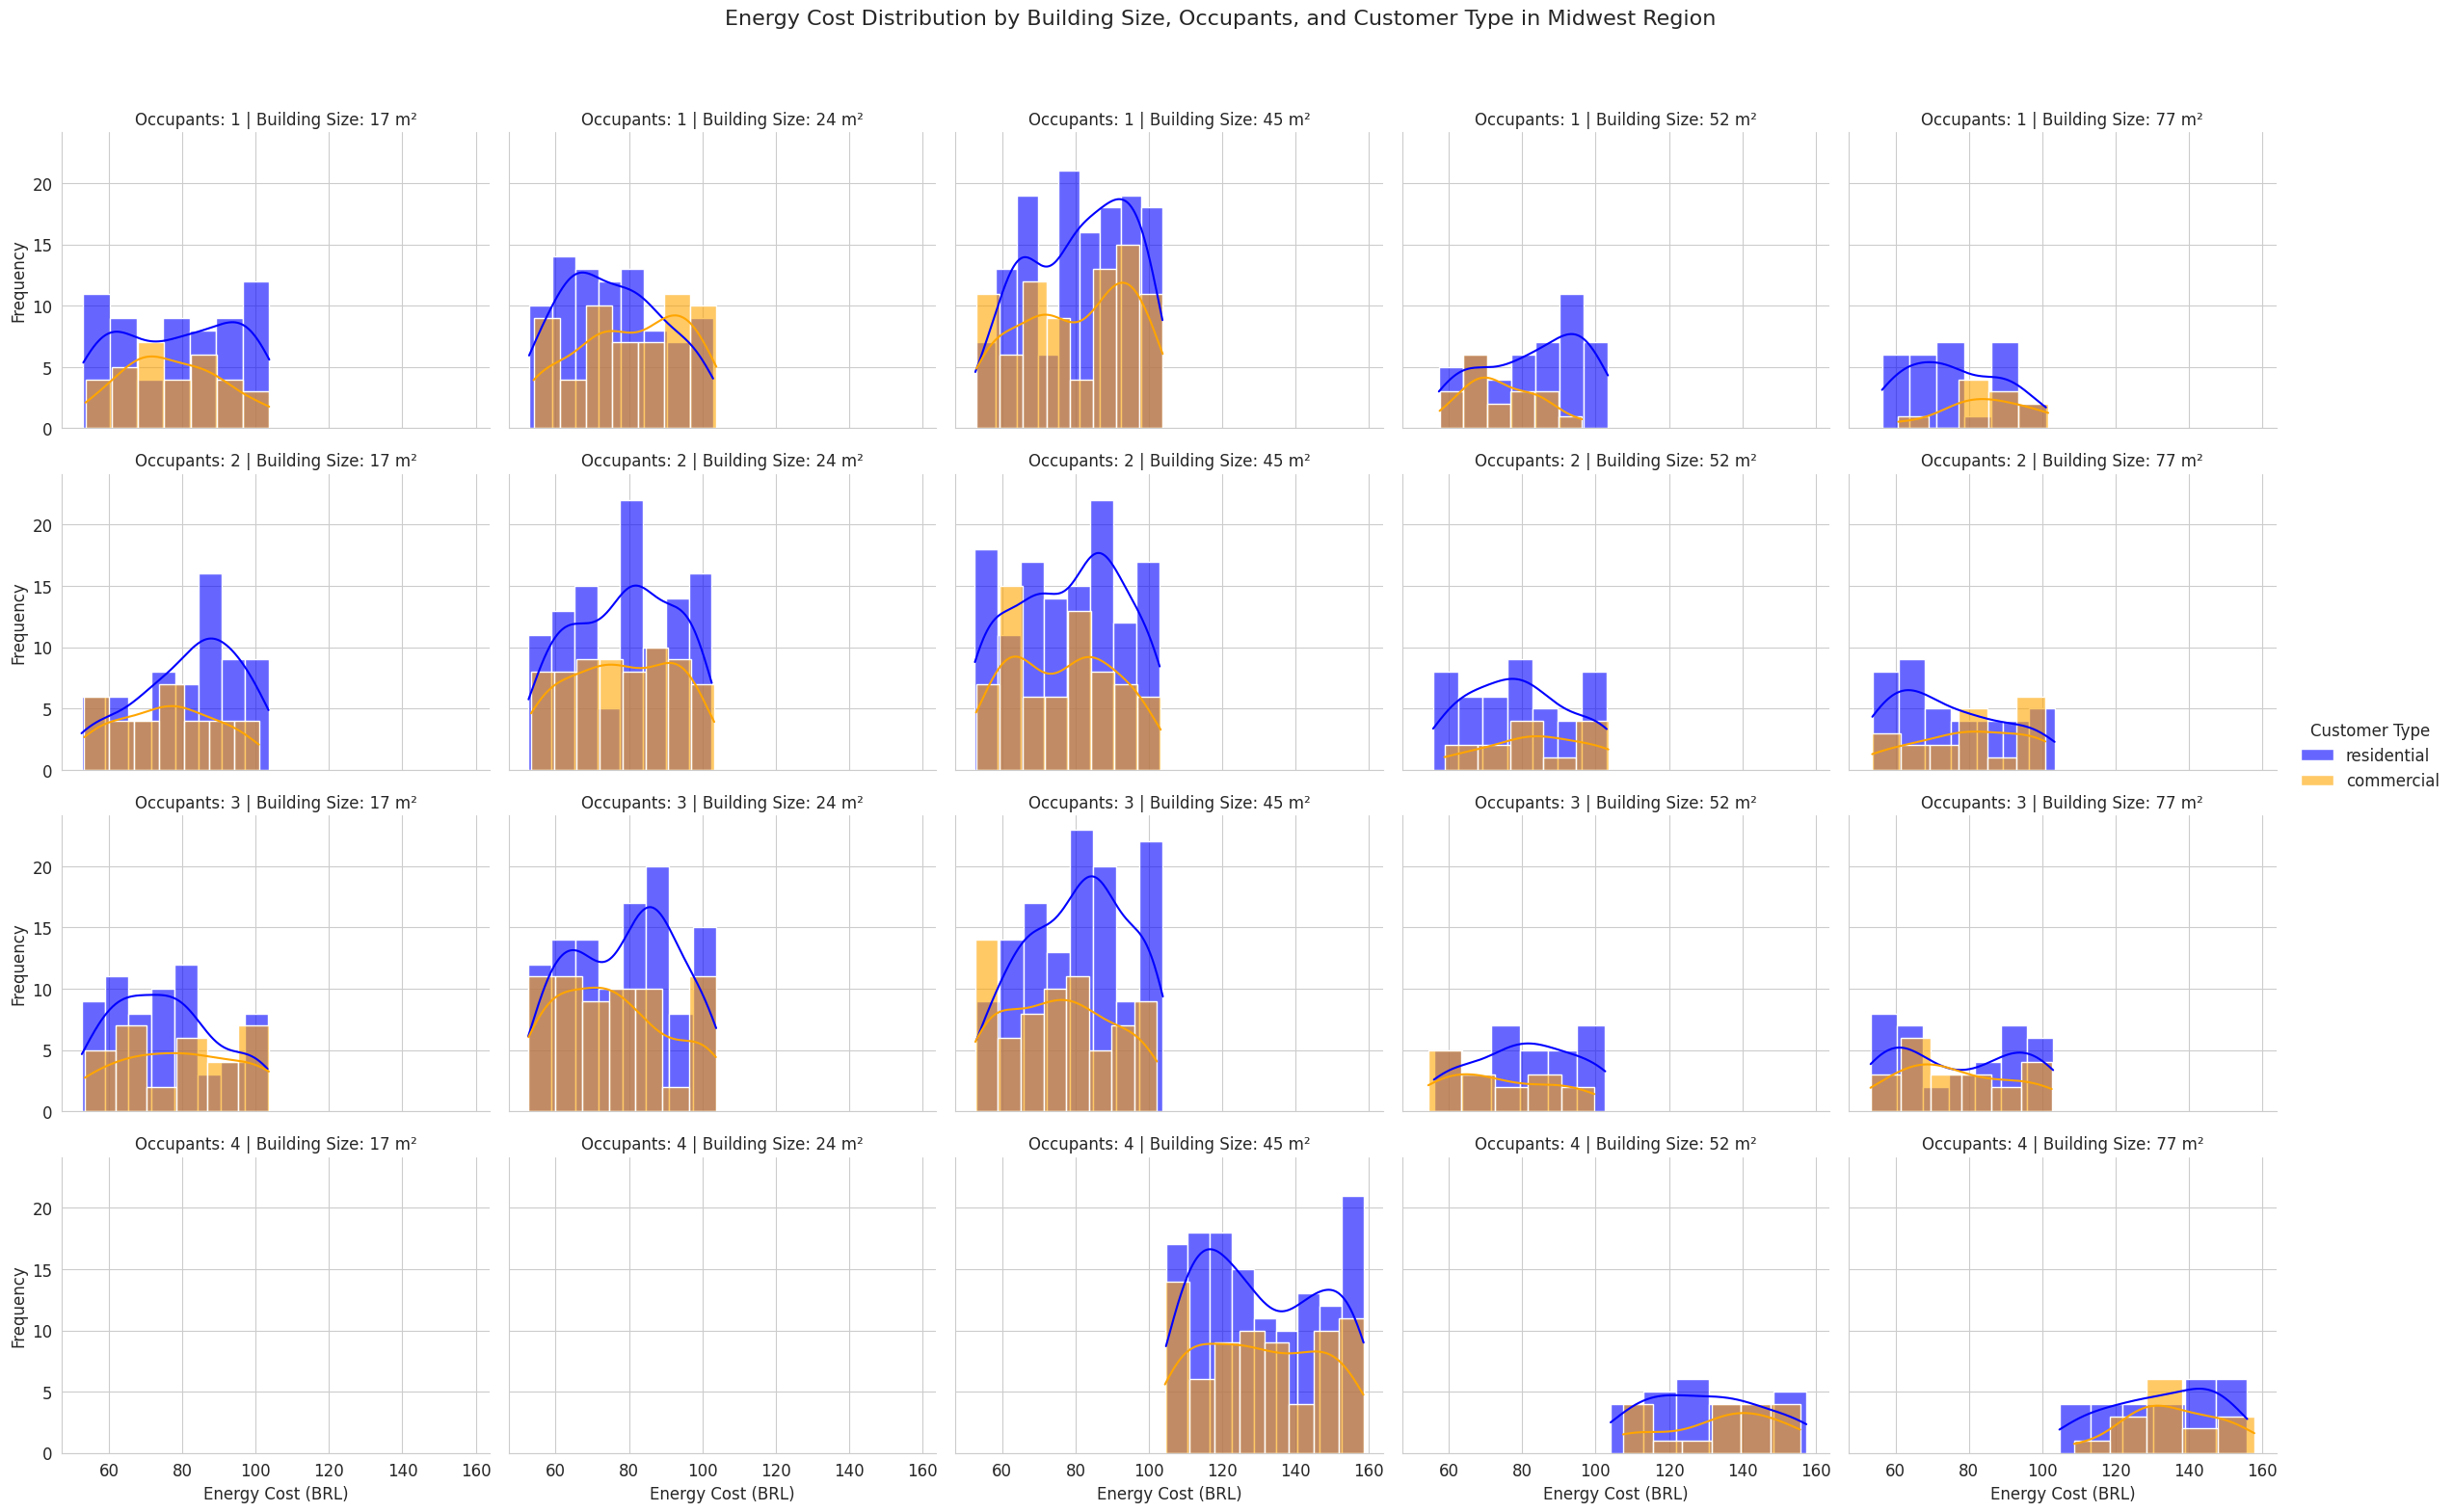

In [ ]:
g = sns.FacetGrid(midwest_df, row='occupants', col='building_size_m2', hue='customer_type', height=4, aspect=1.2, palette={'residential': 'blue', 'commercial': 'orange'}, hue_order=['residential', 'commercial'])
g.map_dataframe(sns.histplot, 'energy_cost_brl', kde=True, alpha=0.6)
g.add_legend(title='Customer Type')
g.set_axis_labels('Energy Cost (BRL)', 'Frequency')
g.set_titles(col_template='Building Size: {col_name} m²', row_template='Occupants: {row_name}')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Energy Cost Distribution by Building Size, Occupants, and Customer Type in Midwest Region', fontsize=16)
plt.show()

**CORRELATION AND REGRESSION**

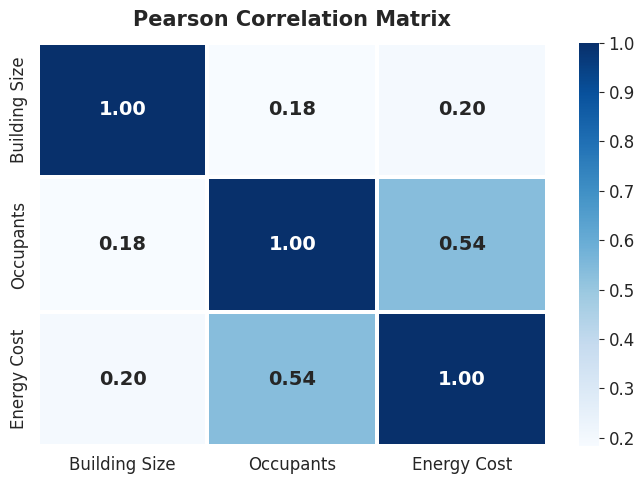

In [ ]:
# Pearson correlation matrix
corr_matrix = df[['building_size_m2', 'occupants', 'energy_cost_brl']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            linewidths=1.5, linecolor='white', annot_kws={'size':14, 'weight':'bold'},
            xticklabels=['Building Size','Occupants','Energy Cost'],
            yticklabels=['Building Size','Occupants','Energy Cost'])
ax.set_title('Pearson Correlation Matrix', fontsize=15, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

In [ ]:
r1, p1 = pearsonr(df['occupants'], df['energy_cost_brl'])
r2, p2 = pearsonr(df['building_size_m2'], df['energy_cost_brl'])

print(f'Occupants r = {r1:.4f}, p = {p1:.6f}')
print(f'Building Size r = {r2:.4f}, p = {p2:.6f}')
print('\nOccupants has a good positive correlation with energy cost (r=0.54).')
print('Building size has a low positive correlation with energy cost (r=0.20).')

Occupants r = 0.5358, p = 0.000000
Building Size r = 0.1959, p = 0.000000

Occupants has a good positive correlation with energy cost (r=0.54).
Building size has a low positive correlation with energy cost (r=0.20).


In [ ]:
# Linear regression on the numerical features

X = df[['building_size_m2', 'occupants']]
y = df['energy_cost_brl']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f'Intercept: {model.intercept_:.2f} BRL')
print(f'Coefficient of building_size_m2: +{model.coef_[0]:.4f} BRL per m²')
print(f'Coefficient of occupants: +{model.coef_[1]:.4f} BRL per occupant')
print(f'R² Score: {r2_score(y, y_pred):.4f}')
print(f'Every extra occupant adds about {model.coef_[1]:.1f} BRL to the energy bill.')
print(f'Every extra m² of building adds about {model.coef_[0]:.2f} BRL.')
print(f'The model explains only {r2_score(y, y_pred)*100:.1f}% of the variance in energy cost i.e R²=0.30.')

Intercept: 53.17 BRL
Coefficient of building_size_m2: +0.1413 BRL per m²
Coefficient of occupants: +12.2130 BRL per occupant
R² Score: 0.2970
Every extra occupant adds about 12.2 BRL to the energy bill.
Every extra m² of building adds about 0.14 BRL.
The model explains only 29.7% of the variance in energy cost i.e R²=0.30.


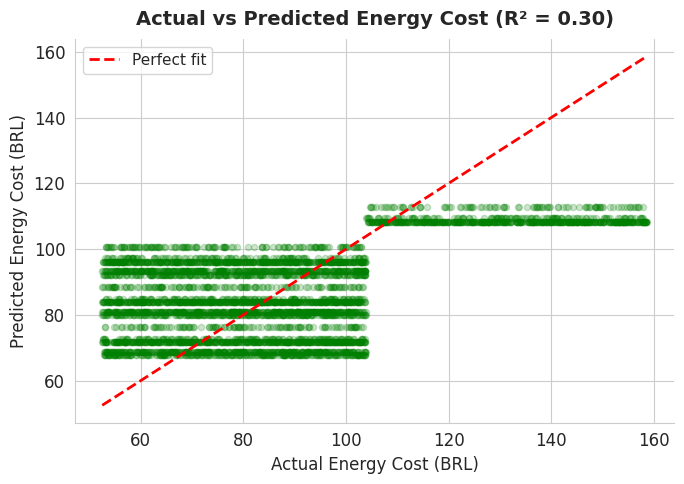

In [ ]:
# Actual vs Predicted energy plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y, y_pred, alpha=0.2, color='g', s=20)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect fit')
ax.set_title(f'Actual vs Predicted Energy Cost (R² = {r2_score(y, y_pred):.2f})',
             fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Actual Energy Cost (BRL)'); ax.set_ylabel('Predicted Energy Cost (BRL)')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

**Hypothesis Testing**

<function matplotlib.pyplot.show(close=None, block=None)>

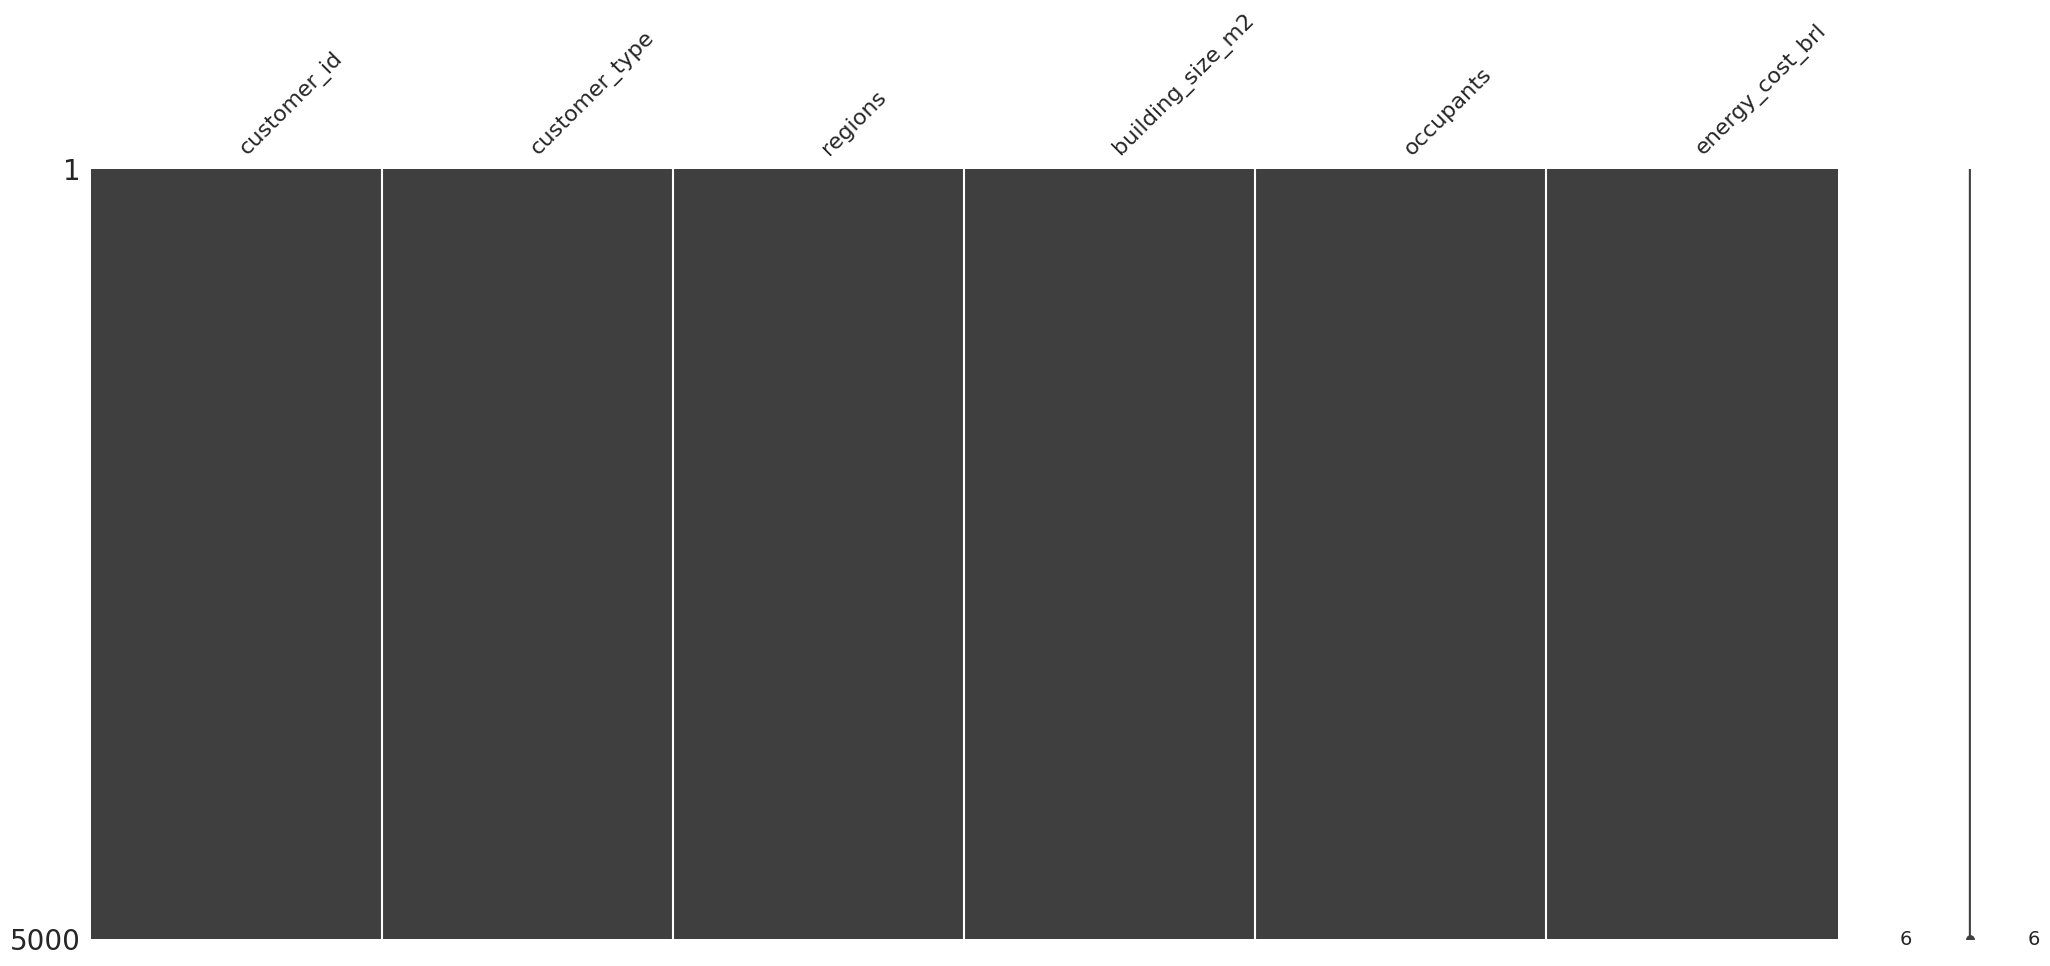

In [ ]:
import missingno as msno

msno.matrix(df)
plt.show

### T-test: Comparing Energy Cost between Residential and Commercial Customer Types

In [ ]:
residential_cost = df[df['customer_type'] == 'residential']['energy_cost_brl']
commercial_cost = df[df['customer_type'] == 'commercial']['energy_cost_brl']

t_stat, p_value = ttest_ind(residential_cost, commercial_cost)

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print("\nThere is a statistically significant difference in energy cost between residential and commercial customer types.")
else:
    print("\nThere is no statistically significant difference in energy cost between residential and commercial customer types.")

T-statistic: 1.1033
P-value: 0.2700

There is no statistically significant difference in energy cost between residential and commercial customer types.


### ANOVA: Comparing Energy Cost Across Different Regions

In [ ]:
northeast_cost = df[df['regions'] == 'Northeast']['energy_cost_brl']
midwest_cost = df[df['regions'] == 'Midwest']['energy_cost_brl']
southeast_cost = df[df['regions'] == 'Southeast']['energy_cost_brl']
north_cost = df[df['regions'] == 'North']['energy_cost_brl']
south_cost = df[df['regions'] == 'South']['energy_cost_brl']

f_stat, p_value = f_oneway(northeast_cost, midwest_cost, southeast_cost, north_cost, south_cost)

print(f'F-statistic: {f_stat:.4f}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print("\nThere is a statistically significant difference in energy cost across different regions.")
else:
    print("\nThere is no statistically significant difference in energy cost across different regions.")

F-statistic: 0.7451
P-value: 0.5612

There is no statistically significant difference in energy cost across different regions.
